# 07 — Generate synthetic minority-class samples (Phase 8)

**Goal:** Load the trained CVAE (Phase 6) and cGAN (Phase 7), sample synthetic images of the under-represented classes, save them to disk as PNGs, and write a `synthetic_manifest.csv` so Phase 10 can mix them with the real training data.

**No new model here — this is just inference + bookkeeping.**

## Design choices

1. **Target per class = 1000 per source.** NV already has thousands of real training images, and MEL and BKL are close to 1000, so we generate nothing for them. We focus generation on the four minority classes — BCC, AKIEC, VASC, and DF — where we only have a few hundred or fewer real samples.
2. **Both generators are used in parallel**, written to separate folders:
   - `data/synthetic/cvae/<CLASS>/synth_cvae_<CLASS>_NNNNNN.png`
   - `data/synthetic/cgan/<CLASS>/synth_cgan_<CLASS>_NNNNNN.png`

   Keeping the two sources separate lets us run three variants in Phase 10: classifier trained with CVAE samples only, with cGAN samples only, and with both. The CVAE samples are blurry but stable across the dataset; the cGAN samples are sharper but noisier. We want to see which the classifier actually prefers rather than assume.
3. **A single `synthetic_manifest.csv`** records every synthetic image with columns `filename, image_path, label, class_name, source` — same shape as `splits.csv`, so Phase 10 can just `pd.concat` them.
4. **We cap synthetic at 1000 per class instead of rebalancing fully.** If we generated 6500 fake DF samples to match NV's count, the training set would be mostly synthetic for that class and the classifier would basically be learning our generator's distribution instead of the real one. Capping at a moderate ratio keeps the real signal dominant.

**Outputs**:
- `data/synthetic/cvae/<CLASS>/*.png`
- `data/synthetic/cgan/<CLASS>/*.png`
- `data/synthetic/synthetic_manifest.csv`
- `results/plots/synthetic_grid_cvae.png`, `synthetic_grid_cgan.png`

## 1. Setup, paths

In [1]:
import sys
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import CLASS_NAMES              # noqa: E402
from src.models.cvae import CVAE                 # noqa: E402
from src.models.cgan import Generator as CGanG   # noqa: E402

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RESULTS  = PROJECT_ROOT / 'results'
SYNTH_ROOT = PROJECT_ROOT / 'data' / 'synthetic'
SYNTH_ROOT.mkdir(parents=True, exist_ok=True)

CVAE_CKPT = RESULTS / 'checkpoints' / 'cvae_best.pt'
CGAN_CKPT = RESULTS / 'checkpoints' / 'cgan_G_epoch30.pt'
# If your best cGAN was a snapshot rather than the final epoch, change to e.g.
#   CGAN_CKPT = RESULTS / 'checkpoints' / 'cgan_G_epoch35.pt'

assert CVAE_CKPT.exists(), f'CVAE checkpoint not found at {CVAE_CKPT}. Run Phase 6 first.'
assert CGAN_CKPT.exists(), f'cGAN checkpoint not found at {CGAN_CKPT}. Run Phase 7 first.'
print(f'CVAE checkpoint -> {CVAE_CKPT}')
print(f'cGAN checkpoint -> {CGAN_CKPT}')

Device: cuda
CVAE checkpoint -> /home/mayarn/skin-cancer/skin-lesion/results/checkpoints/cvae_best.pt
cGAN checkpoint -> /home/mayarn/skin-cancer/skin-lesion/results/checkpoints/cgan_G_epoch30.pt


## 2. Compute how many to generate per class

Look at the actual train-split class counts in `splits.csv` and compute how many synthetic samples each class needs to reach `TARGET_PER_CLASS`.

In [2]:
TARGET_PER_CLASS = 1000   # per source (so up to 1000 from CVAE AND 1000 from cGAN)

splits = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'splits.csv')
train_split = splits[splits['split'] == 'train']

# The 'label' column holds class-name strings (e.g. "MEL", "NV"), so map
# them to the same integer indices used everywhere else via CLASS_NAMES.
name_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
real_counts = (
    train_split['label'].map(name_to_idx).value_counts().sort_index().to_dict()
)
print(f'Real TRAIN counts per class (target per source = {TARGET_PER_CLASS}):\n')
print(f"  {'class':<8}{'real':>7}{'needed':>10}")
n_to_generate = {}
for c in range(len(CLASS_NAMES)):
    real_n = int(real_counts.get(c, 0))
    need = max(0, TARGET_PER_CLASS - real_n)
    n_to_generate[c] = need
    print(f'  {CLASS_NAMES[c]:<8}{real_n:>7}{need:>10}')

total = sum(n_to_generate.values())
print(f'\nTotal synthetic to generate PER SOURCE: {total}')
print(f'Total across both sources:              {total * 2}')

Real TRAIN counts per class (target per source = 1000):

  class      real    needed
  MEL         779       221
  NV         4693         0
  BCC         360       640
  AKIEC       229       771
  BKL         769       231
  DF           80       920
  VASC         99       901

Total synthetic to generate PER SOURCE: 3684
Total across both sources:              7368


## 3. Load both models

In [3]:
# ---- CVAE ----
cvae_ckpt = torch.load(CVAE_CKPT, map_location=DEVICE)
cvae = CVAE(latent_dim=cvae_ckpt['latent_dim'],
            n_classes=cvae_ckpt['n_classes']).to(DEVICE)
cvae.load_state_dict(cvae_ckpt['model_state_dict'])
cvae.eval()
print(f"CVAE loaded (epoch {cvae_ckpt['epoch']}, val_loss {cvae_ckpt['val_loss']:.4f})")

# ---- cGAN ----
cgan_ckpt = torch.load(CGAN_CKPT, map_location=DEVICE)
cgan_G = CGanG(latent_dim=cgan_ckpt['latent_dim'],
               n_classes=cgan_ckpt['n_classes']).to(DEVICE)
cgan_G.load_state_dict(cgan_ckpt['state_dict'])
cgan_G.eval()
print(f"cGAN G loaded (epoch {cgan_ckpt['epoch']})")

CVAE loaded (epoch 59, val_loss 334.3073)
cGAN G loaded (epoch 30)


## 4. Generation helpers

We wrap the two generators behind a single `generate_for_class()` function so the rest of the notebook doesn't have to care which model it's drawing from. Both produce `(3, H, W)` tensors in `[0, 1]`, so the PIL save path is shared. The cGAN's raw output is in `[-1, 1]` (tanh), so we renormalize inline before saving.

In [4]:
BATCH = 32   # generation batch size

def to_pil(img01: torch.Tensor) -> Image.Image:
    """(3, H, W) in [0,1] -> PIL RGB image."""
    arr = (img01.clamp(0, 1).cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr, mode='RGB')


def generate_for_class(source: str, class_idx: int, n: int) -> list[Path]:
    """
    Generate `n` images of `class_idx` using `source` ('cvae' or 'cgan').
    Saves them under data/synthetic/<source>/<CLASS>/ and returns the paths.
    """
    if n == 0:
        return []

    class_name = CLASS_NAMES[class_idx]
    out_dir = SYNTH_ROOT / source / class_name
    out_dir.mkdir(parents=True, exist_ok=True)

    written = []
    idx = 0
    with torch.no_grad():
        while idx < n:
            this_batch = min(BATCH, n - idx)

            if source == 'cvae':
                imgs = cvae.sample(class_idx=class_idx, n=this_batch, device=DEVICE)
            elif source == 'cgan':
                # Match the public sample helper in cgan.py:
                #   z ~ N(0, I), y = class_idx, then renorm to [0, 1]
                z = torch.randn(this_batch, cgan_G.latent_dim, device=DEVICE)
                y = torch.full((this_batch,), class_idx, dtype=torch.long, device=DEVICE)
                raw = cgan_G(z, y)                       # [-1, 1]
                imgs = ((raw + 1.0) / 2.0).clamp(0, 1)
            else:
                raise ValueError(f'unknown source: {source}')

            for k in range(this_batch):
                fname = f'synth_{source}_{class_name}_{idx + k:06d}.png'
                fpath = out_dir / fname
                to_pil(imgs[k]).save(fpath, format='PNG', optimize=False)
                written.append(fpath)

            idx += this_batch
    return written

## 5. Generate, save, record

This is the bulk of the work. Loop over each (source, class) pair, generate, save PNGs, append rows to the manifest list.

In [5]:
manifest_rows = []

for source in ('cvae', 'cgan'):
    print(f'\n=== Generating from {source.upper()} ===')
    for class_idx in range(len(CLASS_NAMES)):
        n = n_to_generate[class_idx]
        class_name = CLASS_NAMES[class_idx]
        if n == 0:
            print(f'  {class_name:<8}skipped (already at target)')
            continue
        paths = generate_for_class(source, class_idx, n)
        print(f'  {class_name:<8}wrote {len(paths)} images')
        for p in paths:
            manifest_rows.append({
                'filename'  : p.name,
                # Store path relative to PROJECT_ROOT so the CSV stays portable
                'image_path': str(p.relative_to(PROJECT_ROOT)),
                'label'     : class_idx,
                'class_name': class_name,
                'source'    : source,
            })

manifest = pd.DataFrame(manifest_rows)
manifest_path = SYNTH_ROOT / 'synthetic_manifest.csv'
manifest.to_csv(manifest_path, index=False)

print(f'\nTotal synthetic images written: {len(manifest)}')
print(f'Manifest: {manifest_path}')

print('\nManifest summary:')
print(manifest.groupby(['source', 'class_name']).size().unstack(fill_value=0))


=== Generating from CVAE ===
  MEL     wrote 221 images
  NV      skipped (already at target)
  BCC     wrote 640 images
  AKIEC   wrote 771 images
  BKL     wrote 231 images
  DF      wrote 920 images
  VASC    wrote 901 images

=== Generating from CGAN ===
  MEL     wrote 221 images
  NV      skipped (already at target)
  BCC     wrote 640 images
  AKIEC   wrote 771 images
  BKL     wrote 231 images
  DF      wrote 920 images
  VASC    wrote 901 images

Total synthetic images written: 7368
Manifest: /home/mayarn/skin-cancer/skin-lesion/data/synthetic/synthetic_manifest.csv

Manifest summary:
class_name  AKIEC  BCC  BKL   DF  MEL  VASC
source                                     
cgan          771  640  231  920  221   901
cvae          771  640  231  920  221   901


## 6. Visual sanity check — grid per source

We load a few PNGs back from disk (rather than reusing the tensors we generated) so this also checks that the save step itself is healthy — wrong color channels, wrong scaling, or a corrupted PIL save would all show up here. Five samples per class is enough to spot mode collapse or pure-noise outputs without making the figure unreadable.

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/synthetic_grid_cvae.png


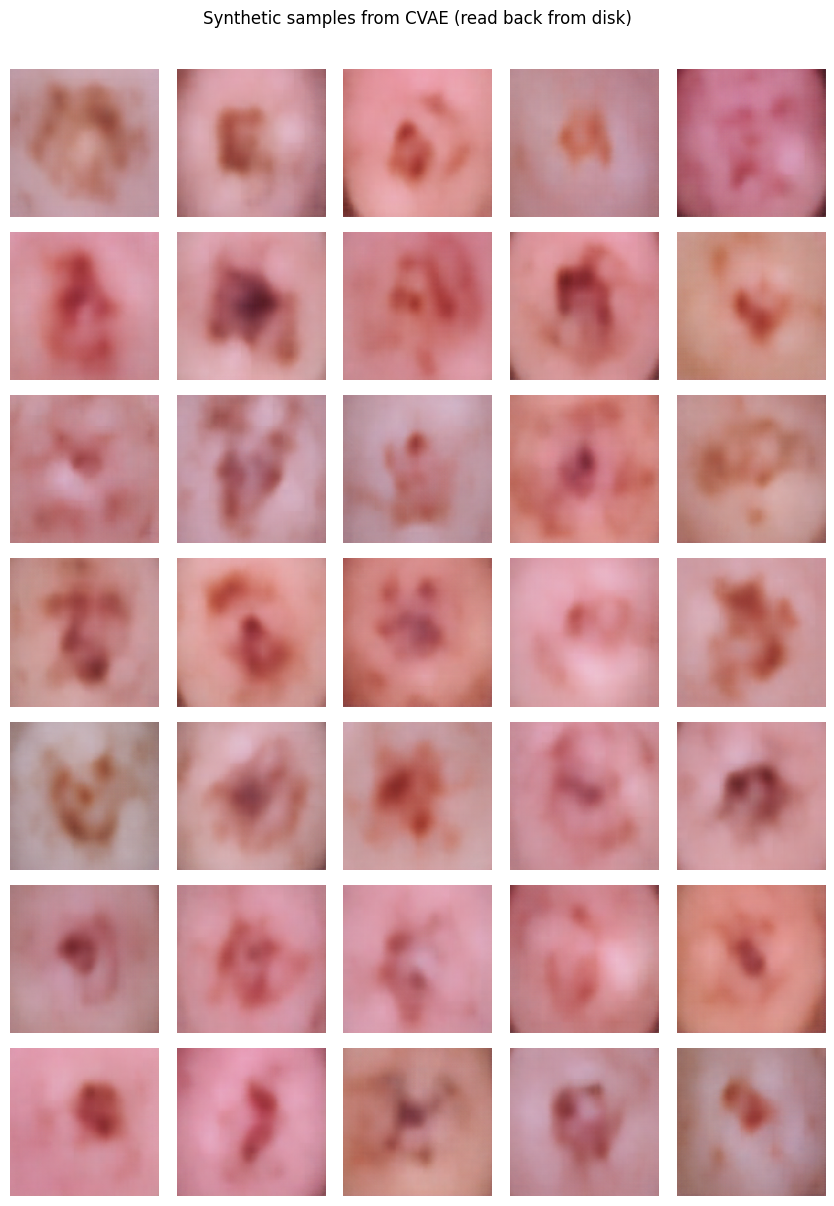

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/synthetic_grid_cgan.png


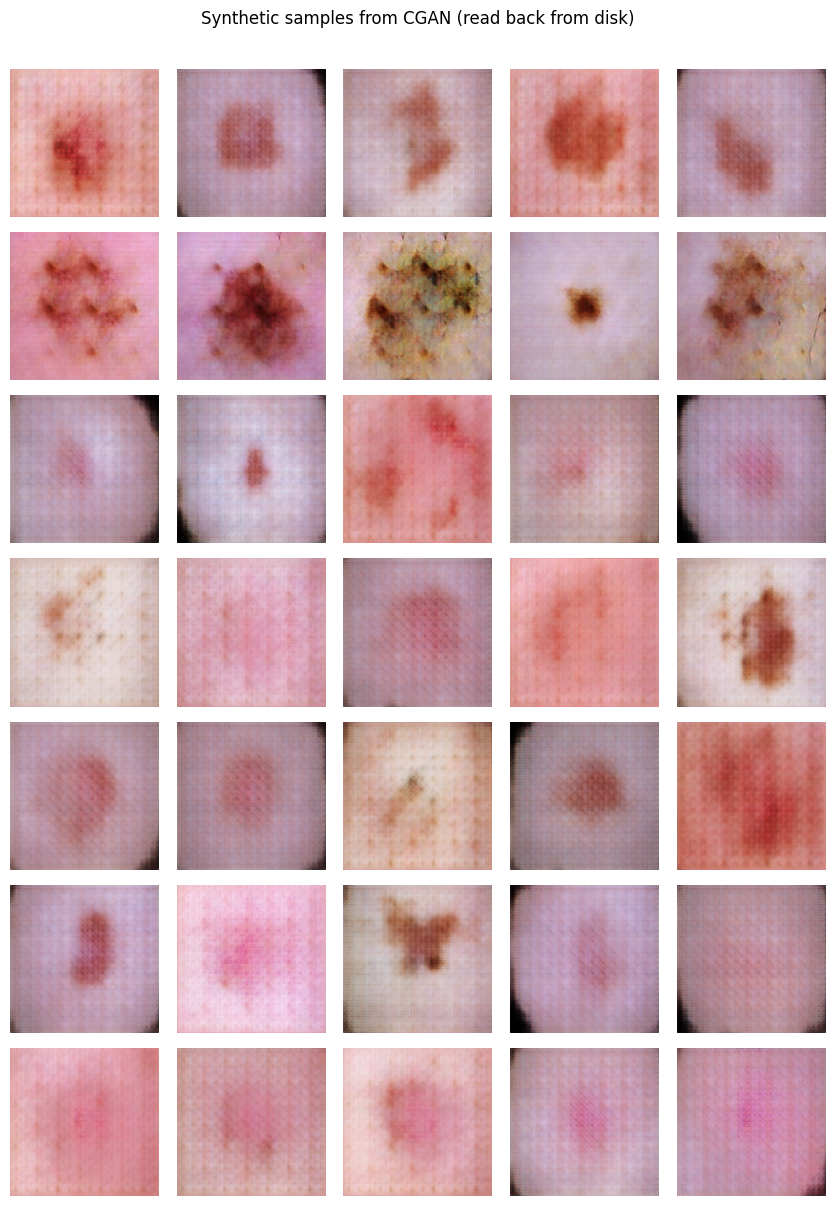

In [6]:
N_PER_CLASS_GRID = 5

def plot_grid_from_disk(source: str) -> None:
    fig, axes = plt.subplots(len(CLASS_NAMES), N_PER_CLASS_GRID,
                             figsize=(1.7 * N_PER_CLASS_GRID, 1.7 * len(CLASS_NAMES)))
    for c, class_name in enumerate(CLASS_NAMES):
        class_dir = SYNTH_ROOT / source / class_name
        files = sorted(class_dir.glob('*.png')) if class_dir.exists() else []
        for j in range(N_PER_CLASS_GRID):
            ax = axes[c, j]
            if j < len(files):
                ax.imshow(Image.open(files[j]))
            else:
                ax.text(0.5, 0.5, 'n/a', ha='center', va='center', fontsize=10)
                ax.set_facecolor('#eeeeee')
            ax.axis('off')
            if j == 0:
                ax.set_ylabel(class_name, fontsize=10, rotation=0,
                              labelpad=28, va='center')
    plt.suptitle(f'Synthetic samples from {source.upper()} (read back from disk)', y=1.01)
    plt.tight_layout()
    out = RESULTS / 'plots' / f'synthetic_grid_{source}.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'saved {out}')
    plt.show()

plot_grid_from_disk('cvae')
plot_grid_from_disk('cgan')

## 7. Summary and what's next

We generated 7,368 synthetic images in total — 3,684 from the CVAE and 3,684 from the cGAN, spread across the six classes that needed augmentation (everything except NV). Both grids show what we expected: the CVAE produces softer, blurrier lesions while the cGAN produces sharper, more varied ones with some background texture. Neither set looks degenerate, so the manifest is ready for downstream use.

The next notebook computes FID per (source, class) against the real training images, which gives us a numerical handle on which generator produces samples closer to the real distribution. After that, the augmented-training experiment in Phase 10 will read `splits.csv` and `synthetic_manifest.csv` together and re-train the classifier to compare per-class macro-F1 against the Phase 5 baseline.

Note: we don't commit `data/synthetic/` to git — the PNGs are regenerable from the checkpoints, and 7,000+ images at 224×224 across two sources is too much to version. The `data/` directory is already in `.gitignore`.